# Explore here

**Prediciendo la diabetes**
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

In [25]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, f1_score

In [2]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df['Outcome'].describe()

count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Outcome, dtype: float64

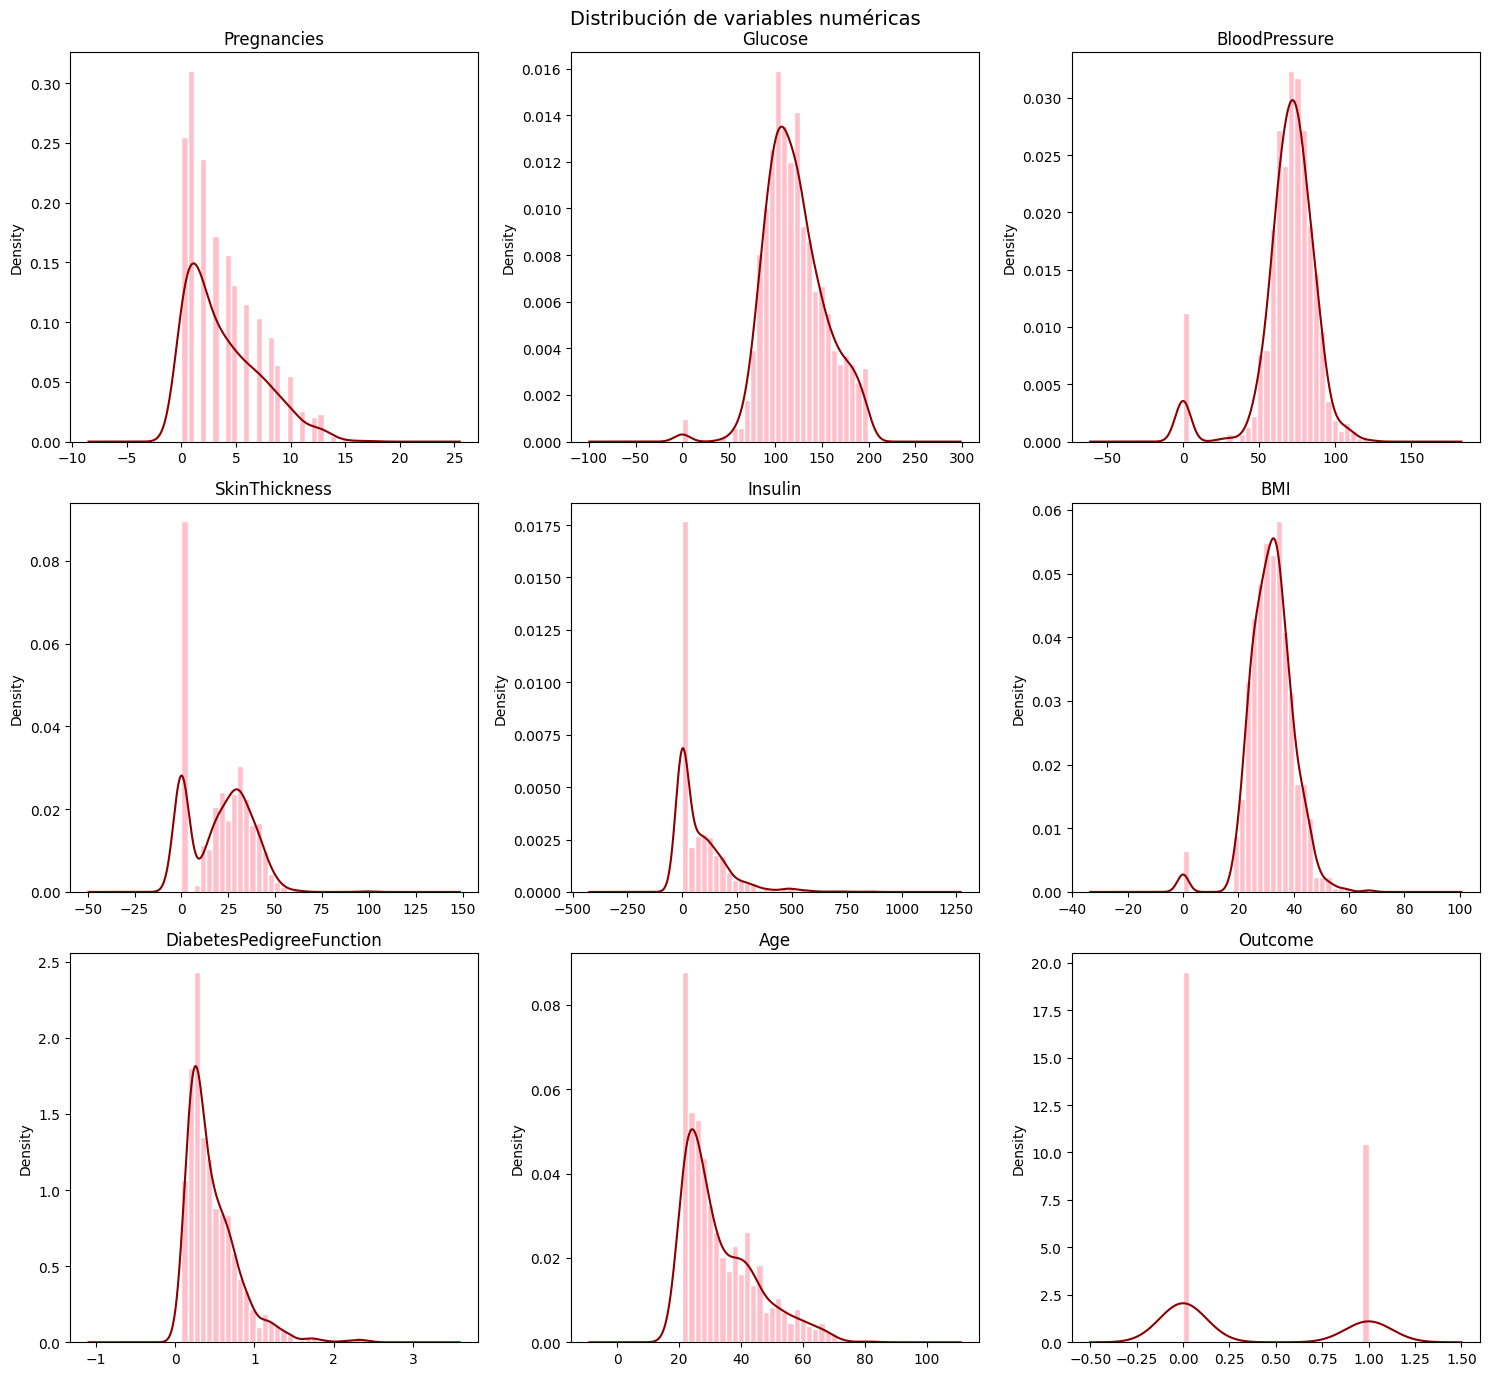

In [9]:
#variables numéricas
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].plot(kind='hist', bins=30, ax=axes[i], color='pink', edgecolor='white', density=True)
    df[col].plot(kind='kde', ax=axes[i], color='darkred')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

Lo que más llama la atención de estos gráficos es que parece que existen muchos datos en 0. Donde más sorprende es en `BloodPresure`, `BMI`, `SkinThickness`, `Insulin` y `Glucose`. No tienen  mucho sentido porque una persona no puede vivir con esto en 0, por lo que se podría intuir que son datos faltantes. Hay que decidir qué hacer con ellos.

In [10]:
# Columnas donde 0 es fisiológicamente imposible
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"{col}: {zeros} ceros ({pct:.1f}%)")

Glucose: 5 ceros (0.7%)
BloodPressure: 35 ceros (4.6%)
SkinThickness: 227 ceros (29.6%)
Insulin: 374 ceros (48.7%)
BMI: 11 ceros (1.4%)


Hay muchos 0 sobretodo en SkinThickness e Insulin, por lo que borrar estos outliers no seria una opción, puesto que nos quedariamos sin casi la mitad del datset. Comprobamos outliers con un boxplot para detectarlos mejor

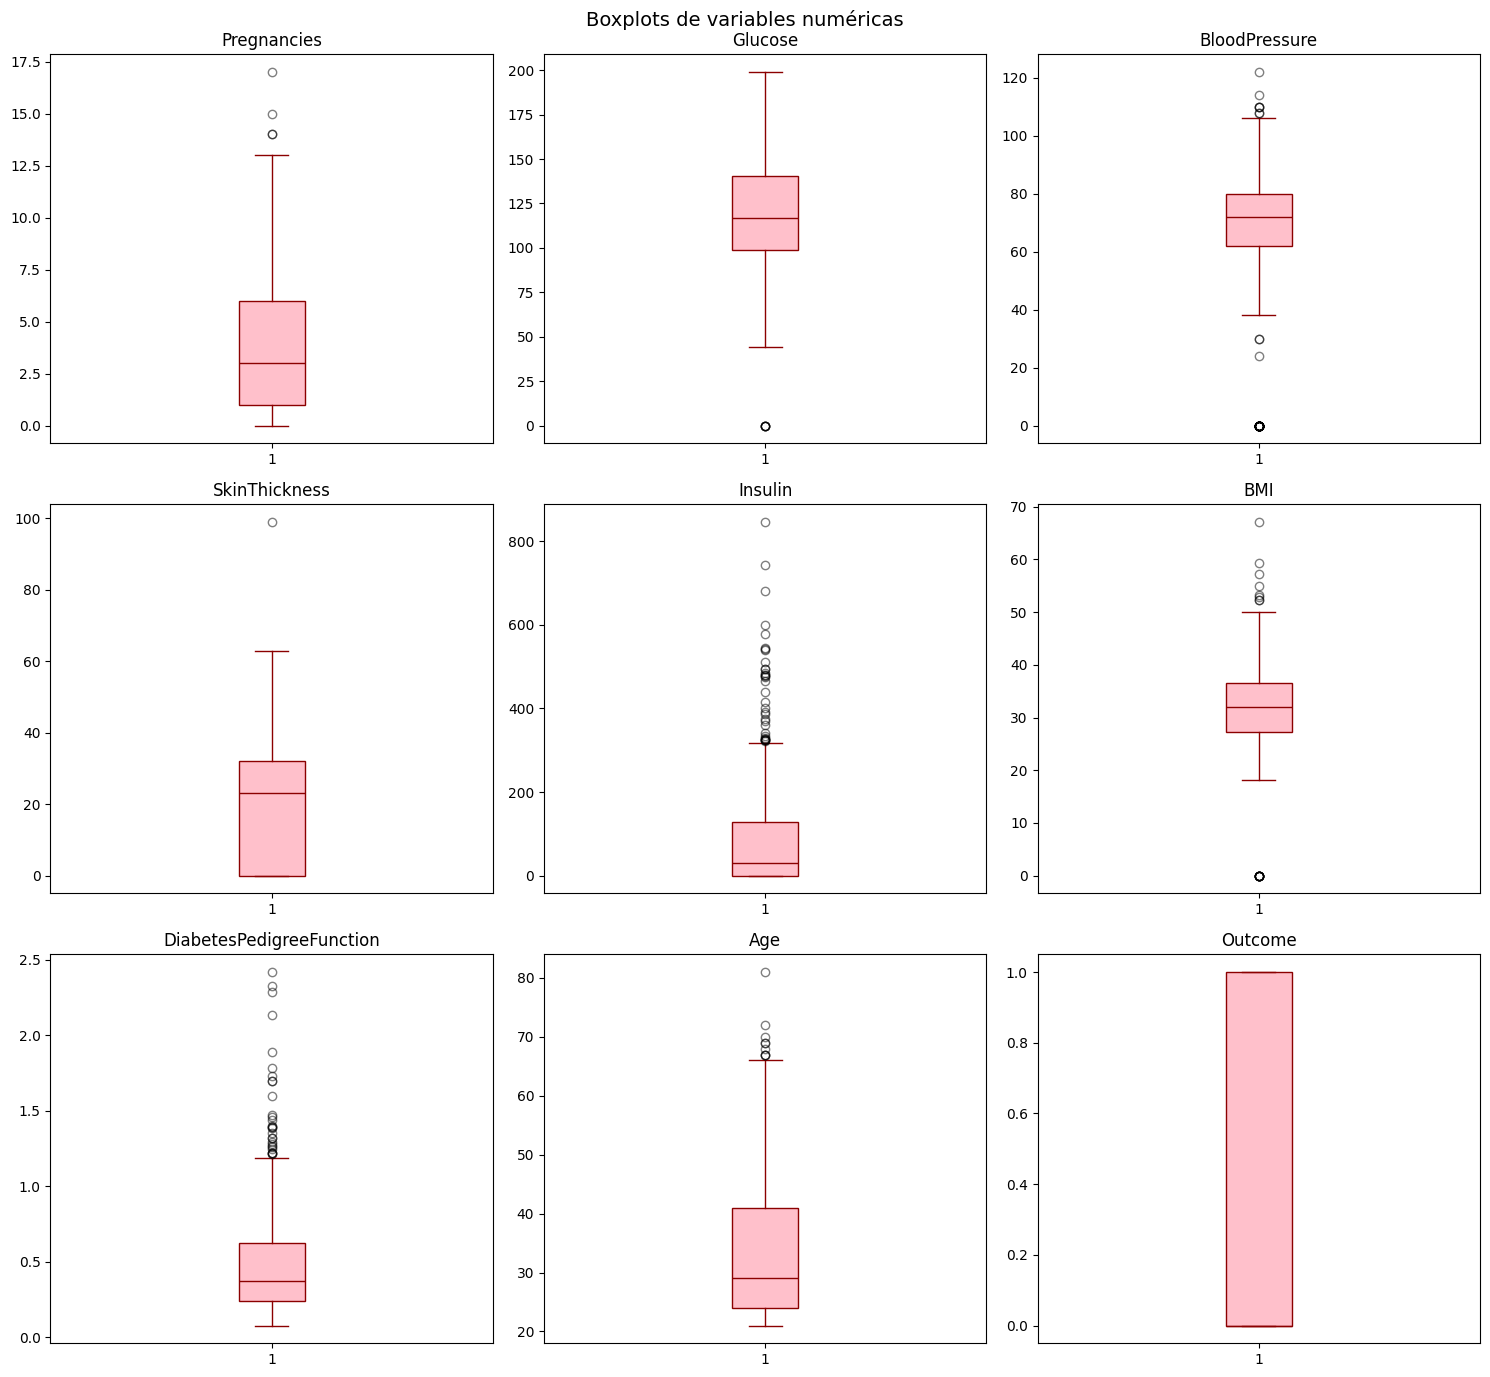

In [11]:
#comprobamos si hay ceros problemáticos y graficamos boxplots para detectar outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='pink', color='darkred'),
                    medianprops=dict(color='darkred'),
                    whiskerprops=dict(color='darkred'),
                    capprops=dict(color='darkred'),
                    flierprops=dict(marker='o', color='darkred', alpha=0.5))
    axes[i].set_title(col)

plt.suptitle('Boxplots de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

Se detectan outliers principalmente en Insulin y DiabetesPedigreeFunction. Sin embargo, dado que este es un dataset médico y los valores extremos son fisiológicamente posibles (niveles muy altos de insulina en diabéticos, historial familiar pronunciado), se decide no eliminarlos. Por lo tanto, para no perjudicar al arbol de decisión que haremos más adelante, lo más coherente es transformar estos 0 con la mediana agrupada con `Outcome` para de esta forma, no poner el mismo número a diabéticos y no diabéticos (usando la mediana global), borrando una diferencia que probablemente es real y que el árbol necesita ver. . 

*Los árboles de decisión son además robustos frente a outliers al trabajar con umbrales en lugar de distancias.

In [14]:
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan) # Reemplazar 0 por NaN para facilitar el cálculo de la mediana
    
    # Rellenar con la mediana según el grupo Outcome
    df[col] = df.groupby('Outcome')[col].transform( 
        lambda x: x.fillna(x.median()) 
    )

#Verificar que no quedan ceros problemáticos
for col in cols_with_zeros:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} ceros restantes")

Glucose: 0 ceros restantes
BloodPressure: 0 ceros restantes
SkinThickness: 0 ceros restantes
Insulin: 0 ceros restantes
BMI: 0 ceros restantes


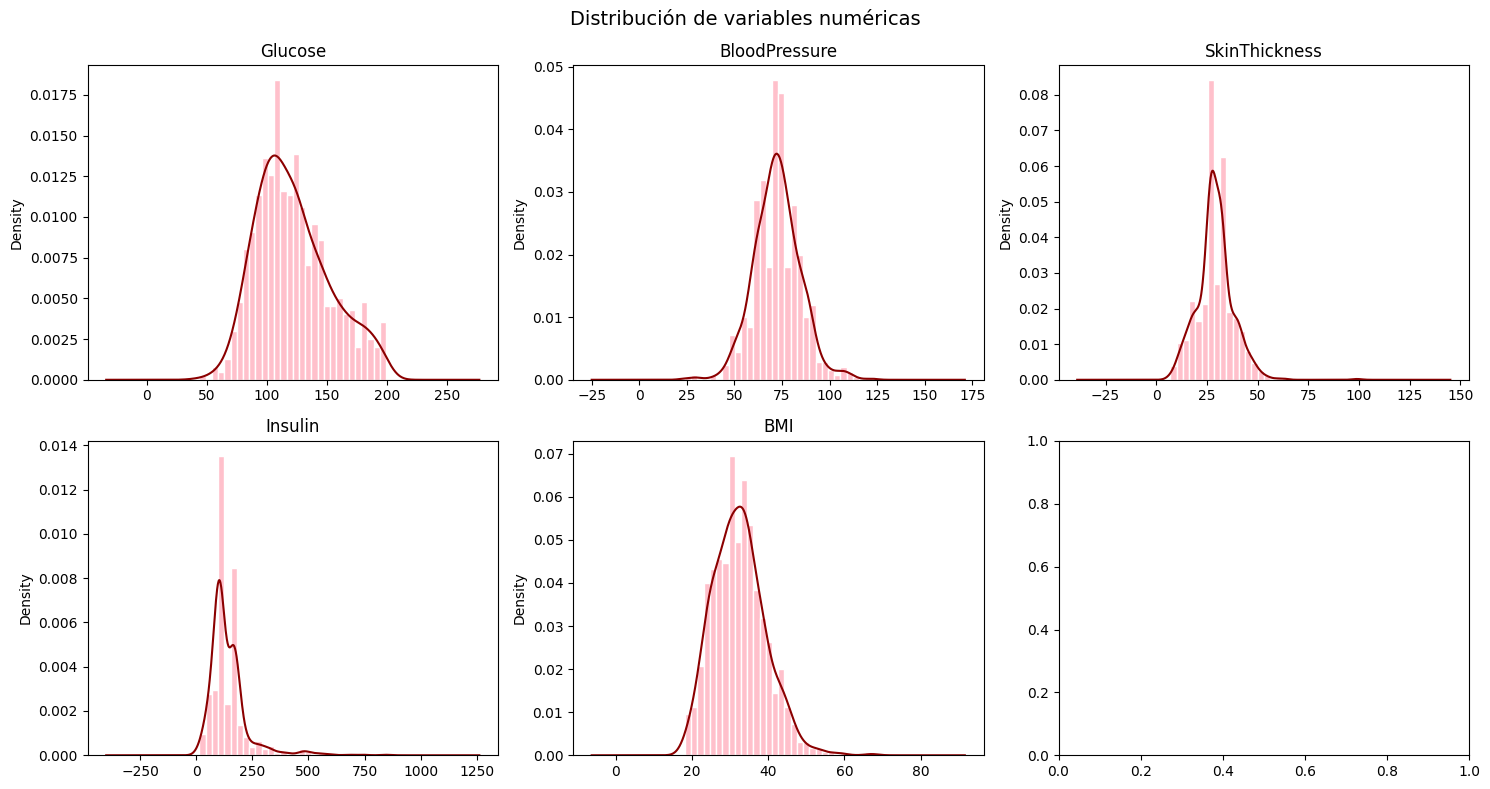

In [15]:
# Volver a graficar para ver la distribución después de la imputación para comprobar
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_with_zeros):
    df[col].plot(kind='hist', bins=30, ax=axes[i], color='pink', edgecolor='white', density=True)
    df[col].plot(kind='kde', ax=axes[i], color='darkred')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

**Análisis multivariante**

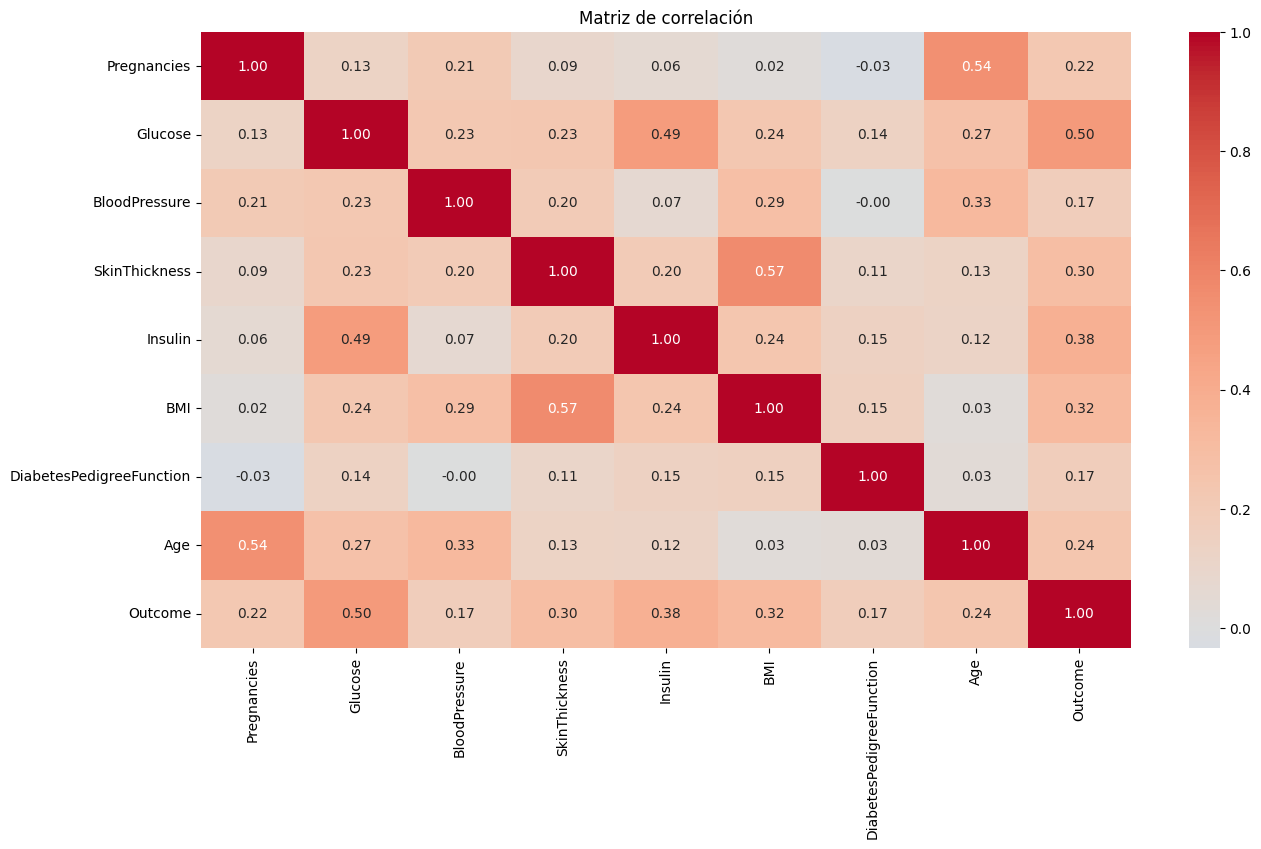

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

Vemos que `outcome`está fuertemente relacionado con `glucose`, `insulin` y `bmi`, y de forma más baja (aunque significativa) con `pregnancies`, `age`, `DiabetesPedigreeFunction` y `BloodPressure`. Por lo tanto todas las variables son datos interesantes a la hora de crear un modelo que prediga quien es más propenso a tener diabetes. 

Otras relaciones a destacar son:
- Insulin con glucose: 0,49:  Tiene sentido directo — la insulina regula el azúcar en sangre, a más glucosa el páncreas produce más insulina
- SkinTickeness y BMI: 0,57: Miden indirectamente lo mismo (la grasa corporal)
- Pregnancies y Age: 0,54: A más edad, más tiempo para haber tenido más embarazos

Estas relaciones confirman la coherencia clínica del dataset. Al usar árboles de decisión, esta multicolinealidad no representa un problema metodológico significativo.

In [17]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribución Outcome en train:\n{y_train.value_counts(normalize=True).round(2)}")
print(f"Distribución Outcome en test:\n{y_test.value_counts(normalize=True).round(2)}")

Train: (614, 8), Test: (154, 8)
Distribución Outcome en train:
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64
Distribución Outcome en test:
Outcome
0    0.64
1    0.36
Name: proportion, dtype: float64


El conjunto de entrenamiento (train) y test mantienen proporciones similares de la variable objetivo (≈65% no diabéticos, ≈35% diabéticos), lo que garantiza que el modelo se entrena y evalúa bajo las mismas condiciones de distribución.

Como todas las variables son numéricas y usamos árbol, no es necesario ni el escalado ni el encoding. 

In [ ]:


# Entrenar el modelo
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_test)

# Evaluar
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        99
           1       0.75      0.82      0.78        55

    accuracy                           0.84       154
   macro avg       0.82      0.83      0.83       154
weighted avg       0.84      0.84      0.84       154



- Vemos que el modelo acierta el 84% de los casos (accuracy), bastante bien para un modelo poco entrenado. 
- Tambien vemos con 1 -recall: que el modelo detecta el 82% de los pacientes diabéticos reales, es decir, solo se le "escapan" 1 de cada 5 diabéticos.
- El modelo es algo más conservador — prefiere no etiquetar a alguien como diabético si no está seguro (precision 75%), pero cuando lo hace detecta bien (recall 82%). Para un diagnóstico médico, ese trade-off es aceptable.

In [19]:
# Comprobamos si hay overfitting comparando train y test. Overfitting se sospecha si la accuracy en train es mucho mayor que en test.
print(f"Accuracy en train: {accuracy_score(y_train, model.predict(X_train)):.2f}")
print(f"Accuracy en test:  {accuracy_score(y_test, y_pred):.2f}")

Accuracy en train: 1.00
Accuracy en test:  0.84


vemos que existe overfitting clásico: El modelo memorizó el training set perfectamente (100%) pero en datos nuevos baja al 84%. El árbol creció sin límite y aprendió hasta el último detalle del train, incluyendo el ruido.

Para poder solucionarlo vamos a "podar" el arbol con max_depth y a encontrar el valor óptimo probando varios

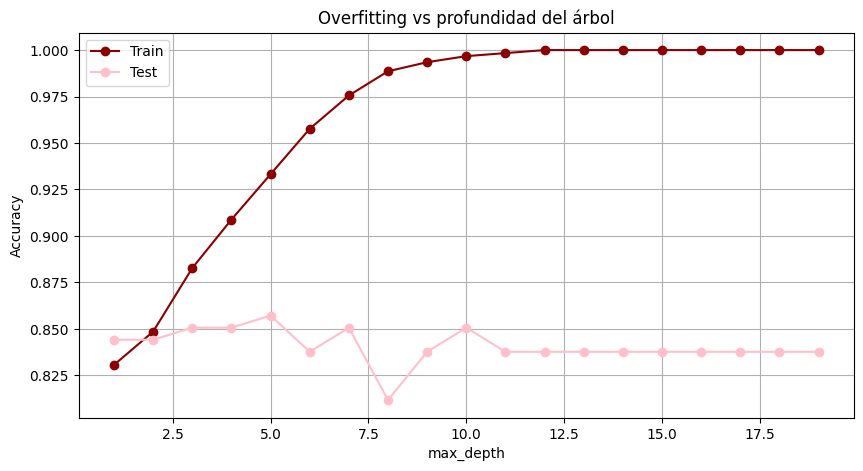

In [20]:
# Para investigar el overfitting, vamos a entrenar árboles con diferentes profundidades y comparar su rendimiento en train y test.
train_scores = []
test_scores = []
depths = range(1, 20)

for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

# Visualizar
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train', marker='o', color='darkred')
plt.plot(depths, test_scores, label='Test', marker='o', color='pink')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting vs profundidad del árbol')
plt.legend()
plt.grid(True)
plt.show()

El pico de test está en max_depth=5 con ~0.858, y a partir de ahí se estabiliza o baja ligeramente mientras train sigue subiendo hasta 1.0. Esa es la divergencia clásica de overfitting. Por lo que vamos a entrenar el nuevo modelo con este valor

In [21]:
model_pruned = DecisionTreeClassifier(max_depth=5, random_state=42)
model_pruned.fit(X_train, y_train)
y_pred_pruned = model_pruned.predict(X_test)

print(f"Accuracy train: {accuracy_score(y_train, model_pruned.predict(X_train)):.2f}")
print(f"Accuracy test:  {accuracy_score(y_test, y_pred_pruned):.2f}")
print(classification_report(y_test, y_pred_pruned))

Accuracy train: 0.93
Accuracy test:  0.86
              precision    recall  f1-score   support

           0       0.87      0.92      0.89        99
           1       0.84      0.75      0.79        55

    accuracy                           0.86       154
   macro avg       0.85      0.83      0.84       154
weighted avg       0.86      0.86      0.86       154



Al aplicar max_depth=5, el overfitting se redujo significativamente (brecha train/test de 0.16 a 0.07) y la accuracy en test mejoró de 0.84 a 0.86. El modelo podado generaliza mejor a datos nuevos, que es el objetivo real de cualquier modelo predictivo.

In [ ]:
# Para optimizar el modelo, vamos a hacer una búsqueda de hiperparámetros con GridSearchCV.

param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # priorizamos detectar diabéticos
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score CV: {grid_search.best_score_:.2f}")

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score CV: 0.81


In [23]:
#Evaluamos el nuevo modelo, a ver si mejora la recall sin sacrificar demasiado la precisión
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test)

print(f"Accuracy train: {accuracy_score(y_train, best_model.predict(X_train)):.2f}")
print(f"Accuracy test:  {accuracy_score(y_test, y_pred_grid):.2f}")
print(classification_report(y_test, y_pred_grid))

Accuracy train: 0.94
Accuracy test:  0.87
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        99
           1       0.83      0.80      0.81        55

    accuracy                           0.87       154
   macro avg       0.86      0.85      0.86       154
weighted avg       0.87      0.87      0.87       154



GridSearchCV confirmó max_depth=5 como profundidad óptima, además, ha añadido criterion='entropy' siento esto una mejora respecto al modelo podado manual. El modelo final alcanza un 87% de accuracy en test y detecta el 80% de los pacientes diabéticos, reduciendo la brecha train/test a 0.07 y mejorando en todas las métricas respecto al modelo base.

In [26]:
resultados = pd.DataFrame({
    'Modelo': ['Base (sin podar)', 'Podado manual (depth=5)', 'GridSearchCV (entropy, depth=5)'],
    'Accuracy Train': [
        accuracy_score(y_train, model.predict(X_train)),
        accuracy_score(y_train, model_pruned.predict(X_train)),
        accuracy_score(y_train, best_model.predict(X_train))
    ],
    'Accuracy Test': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_pruned),
        accuracy_score(y_test, y_pred_grid)
    ],
    'Recall Diabéticos': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_pruned),
        recall_score(y_test, y_pred_grid)
    ],
    'F1 Diabéticos': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_pruned),
        f1_score(y_test, y_pred_grid)
    ]
}).round(2)

print(resultados.to_string(index=False))

                         Modelo  Accuracy Train  Accuracy Test  Recall Diabéticos  F1 Diabéticos
               Base (sin podar)            1.00           0.84               0.82           0.78
        Podado manual (depth=5)            0.93           0.86               0.75           0.79
GridSearchCV (entropy, depth=5)            0.94           0.87               0.80           0.81


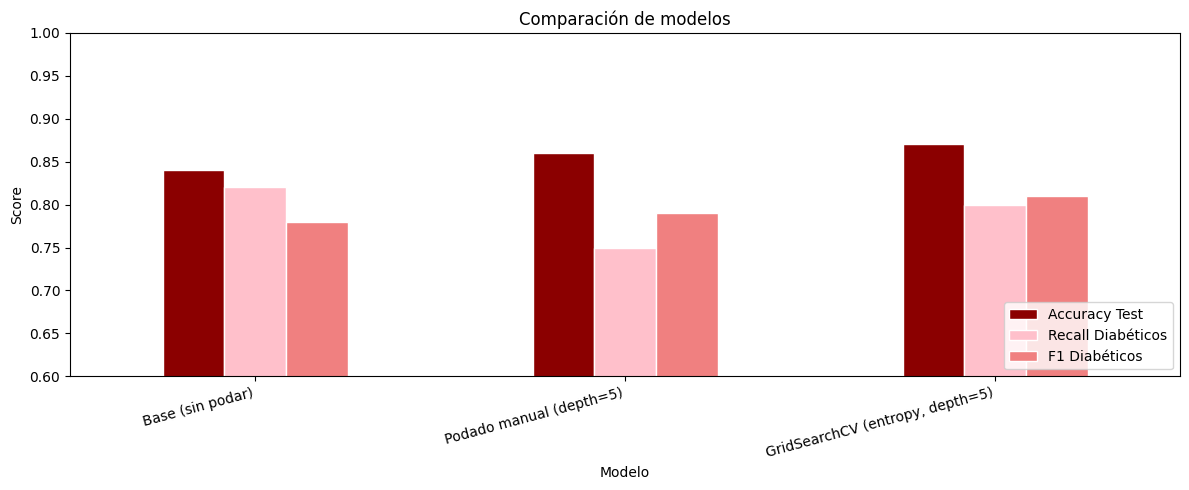

In [ ]:
#graficamos para ver la comparación de modelos en términos de Accuracy, Recall y F1 para los diabéticos
resultados_plot = resultados.set_index('Modelo')[['Accuracy Test', 'Recall Diabéticos', 'F1 Diabéticos']]

resultados_plot.plot(kind='bar', figsize=(12, 5), color=['darkred', 'pink', 'lightcoral'], 
                     edgecolor='white')
plt.title('Comparación de modelos')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

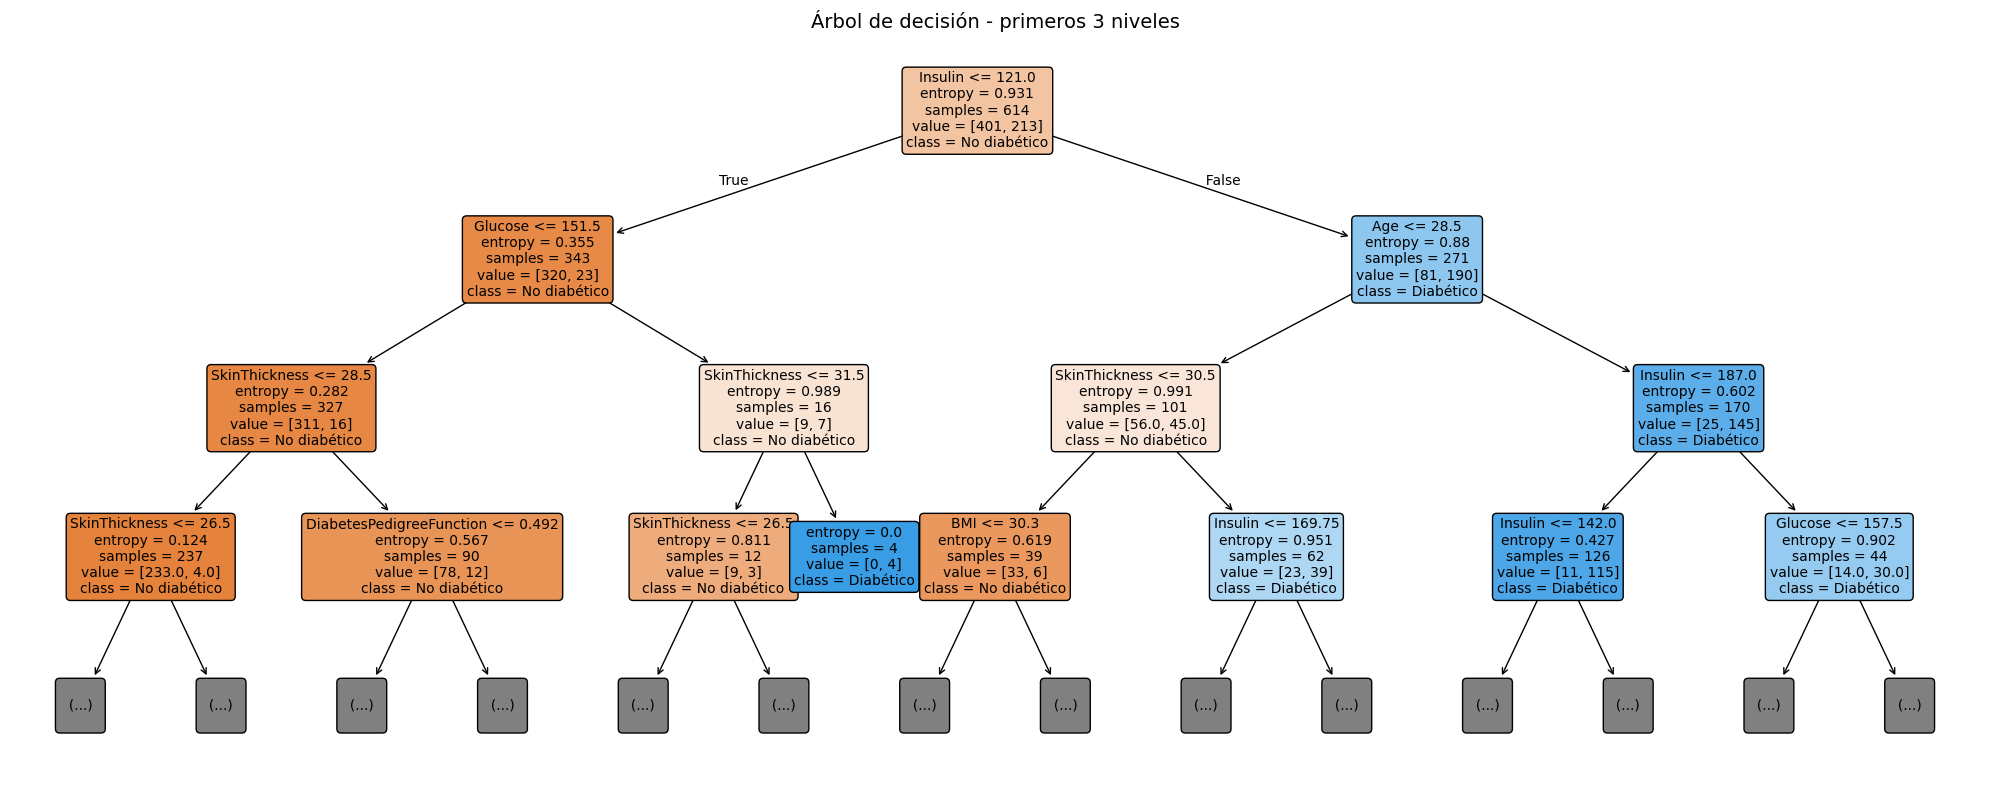

In [ ]:
#graficamos el arbol 
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=['No diabético', 'Diabético'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Solo para visualizar lo 3 primeros niveles y que no sea vea muy denso
plt.title('Árbol de decisión - primeros 3 niveles', fontsize=14)
plt.tight_layout()
plt.show()

El nodo raíz del árbol es `Insulin` <= 121.0, confirmando que es la variable con mayor poder discriminativo. La rama de insulina alta deriva hacia `Age` como segundo criterio, mientras que la de insulina baja usa `Glucose`. Esto es coherente con la fisiología de la diabetes tipo 2.

## 4. Conclusiones

### Puntos clave del análisis

El dataset del Instituto Nacional de Diabetes presentaba un problema importante: 
variables como `Insulin` (48.7%) y `SkinThickness` (29.6%) tenían valores 
faltantes codificados como 0, fisiológicamente imposibles. Se imputaron con la 
mediana agrupada por `Outcome` para preservar las diferencias clínicas entre 
diabéticos y no diabéticos.

El análisis multivariante confirmó que `Glucose`, `Insulin` y `BMI` son las 
variables más correlacionadas con la diabetes, coherente con la fisiología de 
la enfermedad. Las correlaciones entre features (Insulin-Glucose: 0.49, 
SkinThickness-BMI: 0.57) tienen explicación clínica clara y no representan 
un problema para el árbol de decisión.

### Modelo recomendado

El modelo final es un **árbol de decisión con `criterion='entropy'` y 
`max_depth=5`**, optimizado mediante GridSearchCV con validación cruzada de 
5 folds. Es el mejor de los tres modelos evaluados en todas las métricas:

| Modelo | Accuracy Test | Recall Diabéticos |
|---|---|---|
| Base (sin podar) | 0.84 | 0.82 |
| Podado manual (depth=5) | 0.86 | 0.75 |
| GridSearchCV (entropy, depth=5) | 0.87 | 0.80 |

El nodo raíz del árbol es `Insulin <= 121.0` — la variable con mayor poder 
discriminativo — seguida de `Glucose` y `Age`, lo que confirma la coherencia 
clínica del modelo.